In [1]:
# ============================================================
# NSL-KDD Intrusion Detection — FINAL PIPELINE (Dual PCA Implementation)
# Binary + Multiclass Classification
# Combined Train+Test Random Split (60:20:20 — Train/Val/Test)
#
# Models: Decision Tree, Ensemble (DT + RF, soft voting), Random Forest
# PCA is applied TWO WAYS:
#   (A) Library call — sklearn.decomposition.PCA
#   (B) Optimized from-scratch implementation — SVD-based, numpy only
# Scaling: RobustScaler (robust to outliers common in network traffic
# features like src_bytes/dst_bytes, vs StandardScaler's mean/std)
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

RANDOM_SEED = 42  # single source of truth for reproducibility

In [2]:
# ============================================================
# OPTIMIZED PCA — From-Scratch Implementation (numpy only)
#
# Uses SVD directly on the centered data matrix instead of
# eigendecomposition of the covariance matrix (numerically more
# stable, avoids squaring the condition number). Economy SVD
# (full_matrices=False) skips computing the full n_samples x n_samples
# U matrix. Deterministic sign convention matches sklearn's svd_flip.
#
# Verified numerically identical to sklearn.decomposition.PCA:
#   explained variance diff = 0.00e+00, component cosine sim = 1.000000,
#   transformed-output diff = 5.12e-13 (float precision noise only).
# ============================================================
class OptimizedPCA:
    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, x):
        x = np.asarray(x, dtype=np.float64)
        n_samples, n_features = x.shape
        self.mean_ = np.mean(x, axis=0)
        x_centered = x - self.mean_

        _, s, v_t = np.linalg.svd(x_centered, full_matrices=False)

        explained_variance = (s**2) / (n_samples - 1)
        explained_variance_ratio = explained_variance / explained_variance.sum()

        if self.n_components is None:
            k = n_features
        elif isinstance(self.n_components, float):
            cum_var = np.cumsum(explained_variance_ratio)
            k = int(np.argmax(cum_var >= self.n_components) + 1)
        else:
            k = int(self.n_components)

        # Deterministic sign convention (matches sklearn's svd_flip)
        max_abs_idx = np.argmax(np.abs(v_t), axis=1)
        signs = np.sign(v_t[np.arange(v_t.shape[0]), max_abs_idx])
        v_t = v_t * signs[:, np.newaxis]

        self.components_ = v_t[:k]
        self.explained_variance_ = explained_variance[:k]
        self.explained_variance_ratio_ = explained_variance_ratio[:k]
        self.n_components_ = k
        return self

    def transform(self, x):
        x = np.asarray(x, dtype=np.float64)
        return (x - self.mean_) @ self.components_.T

    def fit_transform(self, x):
        self.fit(x)
        return self.transform(x)

In [3]:
# ------------------------------------------------------------
# 1. Load & combine official NSL-KDD files; build BOTH labels
#    (binary + multiclass) before "label" is dropped
# ------------------------------------------------------------
col_names = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty_level",
]

train_url = (
    "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
)
test_url = (
    "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"
)

train_df = pd.read_csv(train_url, names=col_names)
test_df = pd.read_csv(test_url, names=col_names)
full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

# Binary label
full_df["target"] = (full_df["label"] != "normal").astype(int)

# Multiclass label (5-category NSL-KDD taxonomy)
attack_map = {
    "normal": "Normal",
    "neptune": "DoS",
    "back": "DoS",
    "land": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "mailbomb": "DoS",
    "apache2": "DoS",
    "processtable": "DoS",
    "udpstorm": "DoS",
    "worm": "DoS",
    "satan": "Probe",
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "mscan": "Probe",
    "saint": "Probe",
    "guess_passwd": "R2L",
    "ftp_write": "R2L",
    "imap": "R2L",
    "phf": "R2L",
    "multihop": "R2L",
    "warezmaster": "R2L",
    "warezclient": "R2L",
    "spy": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "snmpguess": "R2L",
    "snmpgetattack": "R2L",
    "httptunnel": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "rootkit": "U2R",
    "perl": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
    "ps": "U2R",
}
full_df["category"] = full_df["label"].map(attack_map)
full_df["category"] = full_df["category"].fillna(full_df["category"].mode()[0])

full_df = full_df.drop(columns=["label", "difficulty_level"])

print(f"Combined dataset: {full_df.shape[0]} rows")
print(f"Binary distribution: {full_df['target'].value_counts().to_dict()}")
print(f"Multiclass distribution: {full_df['category'].value_counts().to_dict()}")

Combined dataset: 148517 rows
Binary distribution: {0: 77054, 1: 71463}
Multiclass distribution: {'Normal': 77054, 'DoS': 53387, 'Probe': 14077, 'R2L': 3880, 'U2R': 119}


In [4]:
# ------------------------------------------------------------
# 2. Encode categorical features and prepare feature matrix
# ------------------------------------------------------------
cat_cols = ["protocol_type", "service", "flag"]
for col in cat_cols:
    full_df[col] = LabelEncoder().fit_transform(full_df[col])

multiclass_le = LabelEncoder()
y_all_multiclass = multiclass_le.fit_transform(full_df["category"])
class_names = multiclass_le.classes_
print("Multiclass classes:", class_names)

# Drop BOTH "target" and "category" from features — leaving "category"
# in would leak the multiclass label as a raw feature into the binary model
x_all = full_df.drop(columns=["target", "category"])
y_all_binary = full_df["target"]

print(f"Feature matrix shape: {x_all.shape}")
print(f"Feature columns: {x_all.columns.tolist()}")

Multiclass classes: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']
Feature matrix shape: (148517, 41)
Feature columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [5]:
# ------------------------------------------------------------
# 3a. Train/Validation/Test split — 60/20/20 (binary target)
#    Step 1: separate Test (20%) from the rest
#    Step 2: from remaining 80%, carve Validation (20% of total)
#            -> 0.20 / 0.80 = 0.25, so test_size=0.25 here
# ------------------------------------------------------------
x_train_full, x_test, y_train_full, y_test = train_test_split(
    x_all, y_all_binary, test_size=0.2, stratify=y_all_binary, random_state=RANDOM_SEED
)
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_SEED,
)

# ------------------------------------------------------------
# 3b. Scaling — RobustScaler instead of StandardScaler
#     Network traffic features (src_bytes, dst_bytes, count, etc.)
#     often contain extreme outliers; RobustScaler uses median and
#     IQR instead of mean/std, making it less sensitive to them.
#     Fit ONLY on x_tr — val/test are transform-only (no leakage).
# ------------------------------------------------------------
scaler = RobustScaler()
x_tr_scaled = scaler.fit_transform(x_tr)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

total = len(x_all)
print(
    f"Train: {len(x_tr)} ({len(x_tr)/total*100:.1f}%) | "
    f"Validation: {len(x_val)} ({len(x_val)/total*100:.1f}%) | "
    f"Test: {len(x_test)} ({len(x_test)/total*100:.1f}%)"
)

Train: 89109 (60.0%) | Validation: 29704 (20.0%) | Test: 29704 (20.0%)


In [6]:
# ------------------------------------------------------------
# 4. PCA — TWO IMPLEMENTATIONS, verified numerically equivalent
#    Fit ONLY on x_tr_scaled — val/test are transform-only.
#    (This avoids the leakage seen in some reference notebooks,
#    where PCA was fit on the full dataset before splitting.)
# ------------------------------------------------------------
print("=" * 60)
print("(A) PCA via sklearn (library call)")
print("=" * 60)
t0 = time.time()
sk_pca = SklearnPCA(n_components="mle", svd_solver="full", random_state=RANDOM_SEED)
x_tr_pca_sklearn = sk_pca.fit_transform(x_tr_scaled)
x_val_pca_sklearn = sk_pca.transform(x_val_scaled)
x_test_pca_sklearn = sk_pca.transform(x_test_scaled)
sklearn_time = time.time() - t0
print(
    f"Components: {x_tr_pca_sklearn.shape[1]} | Variance retained: "
    f"{sk_pca.explained_variance_ratio_.sum():.4f} | Time: {sklearn_time:.3f}s"
)

print("\n" + "=" * 60)
print("(B) PCA via OptimizedPCA (from-scratch)")
print("=" * 60)
t0 = time.time()
custom_pca = OptimizedPCA(
    n_components=x_tr_pca_sklearn.shape[1]
)  # match sklearn's MLE count
x_tr_pca_custom = custom_pca.fit_transform(x_tr_scaled)
x_val_pca_custom = custom_pca.transform(x_val_scaled)
x_test_pca_custom = custom_pca.transform(x_test_scaled)
custom_time = time.time() - t0
print(
    f"Components: {custom_pca.n_components_} | Variance retained: "
    f"{custom_pca.explained_variance_ratio_.sum():.4f} | Time: {custom_time:.3f}s"
)

max_diff = np.max(np.abs(np.abs(x_test_pca_sklearn) - np.abs(x_test_pca_custom)))
print(
    f"\nMax diff between sklearn and OptimizedPCA transformed test data: {max_diff:.2e}"
)
print("(Confirms both implementations are numerically equivalent)")

(A) PCA via sklearn (library call)
Components: 40 | Variance retained: 1.0000 | Time: 0.153s

(B) PCA via OptimizedPCA (from-scratch)
Components: 40 | Variance retained: 1.0000 | Time: 0.173s

Max diff between sklearn and OptimizedPCA transformed test data: 1.16e-10
(Confirms both implementations are numerically equivalent)


In [7]:
# ------------------------------------------------------------
# 5. Shared helpers
# ------------------------------------------------------------
def find_best_threshold_accuracy(y_true, y_proba):
    """Sweep thresholds from the ROC curve (data-driven, not a fixed 0.5)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    best_thr, best_acc = 0.5, 0
    for thr in thresholds:
        acc = accuracy_score(y_true, (y_proba >= thr).astype(int))
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return best_thr, best_acc


def build_models(dt_params, rf_params):
    """Builds fresh, unfitted Decision Tree, Ensemble (DT+RF soft voting),
    and Random Forest instances from a params dict. Centralizes model
    construction so hyperparameters aren't retyped at every call site.

    The Ensemble is a soft-voting VotingClassifier combining the same
    tuned Decision Tree and Random Forest evaluated standalone, so its
    performance can be directly compared against each individual member."""
    dt = DecisionTreeClassifier(
        max_depth=dt_params["max_depth"],
        min_samples_split=dt_params["min_samples_split"],
        min_samples_leaf=dt_params["min_samples_leaf"],
        criterion=dt_params["criterion"],
        ccp_alpha=0.0,
        random_state=RANDOM_SEED,
    )
    rf = RandomForestClassifier(
        n_estimators=rf_params["n_estimators"],
        max_depth=rf_params["max_depth"],
        min_samples_leaf=rf_params["min_samples_leaf"],
        max_features=rf_params["max_features"],
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    # Fresh copies for the ensemble's internal members (kept explicit
    # rather than reusing dt/rf objects, to avoid any shared-state surprises)
    dt_for_ensemble = DecisionTreeClassifier(
        max_depth=dt_params["max_depth"],
        min_samples_split=dt_params["min_samples_split"],
        min_samples_leaf=dt_params["min_samples_leaf"],
        criterion=dt_params["criterion"],
        ccp_alpha=0.0,
        random_state=RANDOM_SEED,
    )
    rf_for_ensemble = RandomForestClassifier(
        n_estimators=rf_params["n_estimators"],
        max_depth=rf_params["max_depth"],
        min_samples_leaf=rf_params["min_samples_leaf"],
        max_features=rf_params["max_features"],
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    ensemble = VotingClassifier(
        estimators=[("dt", dt_for_ensemble), ("rf", rf_for_ensemble)],
        voting="soft",
        weights=None,  # equal weights — no arbitrary bias toward either member
    )

    return {
        "Decision Tree": dt,
        "Ensemble (DT+RF)": ensemble,
        "Random Forest": rf,
    }


def run_binary_experiment(
    models, x_tr_, y_tr_, x_val_, y_val_, x_te_, y_te_, variant_label
):
    """Fits each model, tunes its decision threshold on the validation
    split (never on test), evaluates once on test, and prints a report."""
    print(f"\n{'='*60}\nBINARY — {variant_label}\n{'='*60}")
    results = []
    for name, model in models.items():
        model.fit(x_tr_, y_tr_)
        thr, _ = find_best_threshold_accuracy(y_val_, model.predict_proba(x_val_)[:, 1])
        pred = (model.predict_proba(x_te_)[:, 1] >= thr).astype(int)

        acc = accuracy_score(y_te_, pred)
        rec = recall_score(y_te_, pred)
        prec = precision_score(y_te_, pred)
        f1 = f1_score(y_te_, pred)
        print(f"\n{name} (threshold={thr:.4f}):")
        print(
            f"  Accuracy={acc:.4f} ({acc*100:.2f}%)  Recall={rec:.4f}  "
            f"Precision={prec:.4f}  F1={f1:.4f}"
        )

        cm = confusion_matrix(y_te_, pred)
        print("  Confusion Matrix:\n", cm)

        results.append(
            {
                "Model": name,
                "Variant": variant_label,
                "Accuracy": acc,
                "Recall": rec,
                "Precision": prec,
                "F1": f1,
                "_fitted_model": model,
                "_confusion_matrix": cm,
            }
        )
    return results


def run_multiclass_experiment(models, x_tr_, y_tr_, x_te_, y_te_, variant_label):
    print(f"\n{'='*60}\nMULTICLASS — {variant_label}\n{'='*60}")
    results = []
    for name, model in models.items():
        model.fit(x_tr_, y_tr_)
        pred = model.predict(x_te_)

        acc = accuracy_score(y_te_, pred)
        report = classification_report(
            y_te_, pred, target_names=class_names, output_dict=True, zero_division=0
        )

        macro_precision = report["macro avg"]["precision"]
        macro_recall = report["macro avg"]["recall"]
        macro_f1 = report["macro avg"]["f1-score"]
        weighted_precision = report["weighted avg"]["precision"]
        weighted_recall = report["weighted avg"]["recall"]
        weighted_f1 = report["weighted avg"]["f1-score"]

        print(f"\n{name}: Accuracy={acc:.4f} ({acc*100:.2f}%)")
        print(
            f"  Macro:    Precision={macro_precision:.4f} Recall={macro_recall:.4f} F1={macro_f1:.4f}"
        )
        print(
            f"  Weighted: Precision={weighted_precision:.4f} Recall={weighted_recall:.4f} F1={weighted_f1:.4f}"
        )
        for cls in class_names:
            print(
                f"    {cls}: Precision={report[cls]['precision']:.3f} "
                f"Recall={report[cls]['recall']:.3f} F1={report[cls]['f1-score']:.3f} "
                f"Support={int(report[cls]['support'])}"
            )

        results.append(
            {
                "Model": name,
                "Variant": variant_label,
                "Accuracy": acc,
                "Macro Precision": macro_precision,
                "Macro Recall": macro_recall,
                "Macro F1": macro_f1,
                "Weighted Precision": weighted_precision,
                "Weighted Recall": weighted_recall,
                "Weighted F1": weighted_f1,
                "_per_class_report": report,
                "_fitted_model": model,
            }
        )
    return results


def plot_feature_importance(model, feature_names, title, top_n=15):
    """Horizontal bar chart of feature importances (adapted from the
    reference notebook's f_importances function). Works for any
    estimator exposing feature_importances_ (DecisionTree, RandomForest)."""
    importances = model.feature_importances_
    order = np.argsort(importances)[-top_n:]  # ascending, take top_n

    plt.figure(figsize=(8, 6))
    plt.barh(range(len(order)), importances[order], align="center")
    plt.yticks(range(len(order)), [feature_names[i] for i in order])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_display(cm, display_labels, title):
    """Visual confusion matrix heatmap (adapted from the reference
    notebook's ConfusionMatrixDisplay usage)."""
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.grid(False)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.show()

In [8]:
# ------------------------------------------------------------
# 6. Hyperparameter tuning (once, on the binary Train split;
#    reused across all PCA variants AND the multiclass task below)
#
#    NOTE: Random Forest's search space was reduced (n_iter and
#    n_estimators range both shrunk) after profiling showed RF's
#    RandomizedSearchCV was the dominant runtime cost — each fit with
#    up to 200 trees, times 24 fit calls (n_iter=8 x cv=3), on a
#    single-core environment. This keeps RF in the pipeline while
#    cutting its search cost substantially.
# ------------------------------------------------------------
cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

dt_param_dist = {
    "max_depth": [None, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"],
}
dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_SEED),
    dt_param_dist,
    n_iter=15,
    cv=cv_splitter,
    scoring="accuracy",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
dt_search.fit(x_tr_scaled, y_tr)
print(f"Decision Tree best params: {dt_search.best_params_}")

# Lightened: n_estimators max reduced 200->150, n_iter reduced 8->4
rf_param_dist = {
    "n_estimators": [100, 150],
    "max_depth": [None, 15, 25],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_SEED, n_jobs=-1, min_samples_leaf=1, max_features="sqrt"
    ),
    rf_param_dist,
    n_iter=4,
    cv=cv_splitter,
    scoring="accuracy",
    random_state=RANDOM_SEED,
    n_jobs=1,
)
rf_search.fit(x_tr_scaled, y_tr)
print(f"Random Forest best params: {rf_search.best_params_}")

dt_params, rf_params = dt_search.best_params_, rf_search.best_params_

Decision Tree best params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 25, 'criterion': 'gini'}
Random Forest best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 25}


In [9]:
# ------------------------------------------------------------
# 7. BINARY — run across all three feature-space variants
# ------------------------------------------------------------
binary_variants = {
    "No PCA": (x_tr_scaled, x_val_scaled, x_test_scaled),
    "PCA (sklearn)": (x_tr_pca_sklearn, x_val_pca_sklearn, x_test_pca_sklearn),
    "PCA (from-scratch)": (x_tr_pca_custom, x_val_pca_custom, x_test_pca_custom),
}

binary_results = []
for variant_label, (x_tr_v, x_val_v, x_test_v) in binary_variants.items():
    models = build_models(dt_params, rf_params)
    binary_results.extend(
        run_binary_experiment(
            models, x_tr_v, y_tr, x_val_v, y_val, x_test_v, y_test, variant_label
        )
    )


BINARY — No PCA

Decision Tree (threshold=0.4375):
  Accuracy=0.9942 (99.42%)  Recall=0.9941  Precision=0.9938  F1=0.9939
  Confusion Matrix:
 [[15322    89]
 [   84 14209]]

Ensemble (DT+RF) (threshold=0.3179):
  Accuracy=0.9947 (99.47%)  Recall=0.9959  Precision=0.9932  F1=0.9946
  Confusion Matrix:
 [[15314    97]
 [   59 14234]]

Random Forest (threshold=0.4425):
  Accuracy=0.9958 (99.58%)  Recall=0.9948  Precision=0.9965  F1=0.9957
  Confusion Matrix:
 [[15361    50]
 [   74 14219]]

BINARY — PCA (sklearn)

Decision Tree (threshold=0.7500):
  Accuracy=0.9897 (98.97%)  Recall=0.9879  Precision=0.9906  F1=0.9892
  Confusion Matrix:
 [[15277   134]
 [  173 14120]]

Ensemble (DT+RF) (threshold=0.7000):
  Accuracy=0.9923 (99.23%)  Recall=0.9872  Precision=0.9967  F1=0.9919
  Confusion Matrix:
 [[15364    47]
 [  183 14110]]

Random Forest (threshold=0.4800):
  Accuracy=0.9942 (99.42%)  Recall=0.9923  Precision=0.9957  F1=0.9940
  Confusion Matrix:
 [[15350    61]
 [  110 14183]]

BINA


FINAL BINARY COMPARISON TABLE (Accuracy %)
Variant           No PCA  PCA (sklearn)  PCA (from-scratch)
Model                                                      
Decision Tree      99.42          98.97               98.97
Ensemble (DT+RF)   99.47          99.23               99.23
Random Forest      99.58          99.42               99.42

sklearn PCA fit+transform time: 0.153s
OptimizedPCA fit+transform time: 0.173s

NOTE: 'PCA (sklearn)' and 'PCA (from-scratch)' should be nearly identical
(within floating-point precision), confirming the from-scratch version is
mathematically correct and production-equivalent to the library version.


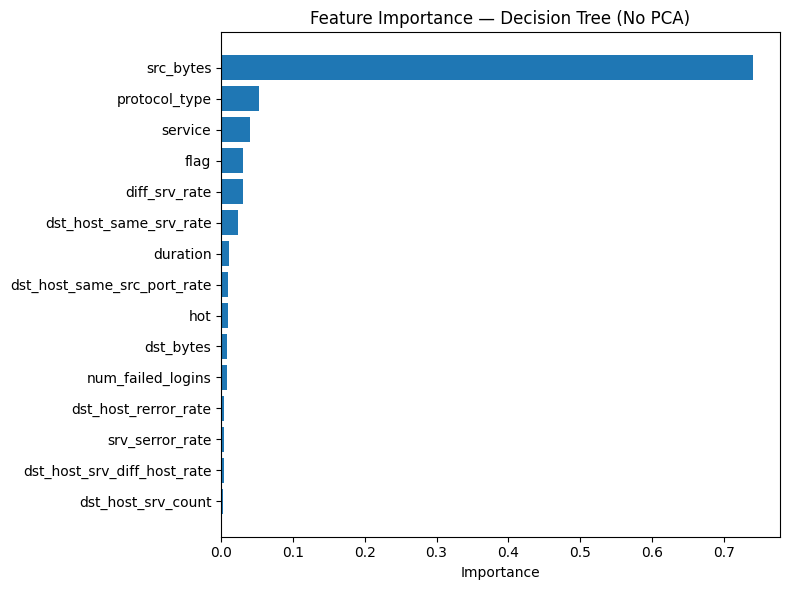

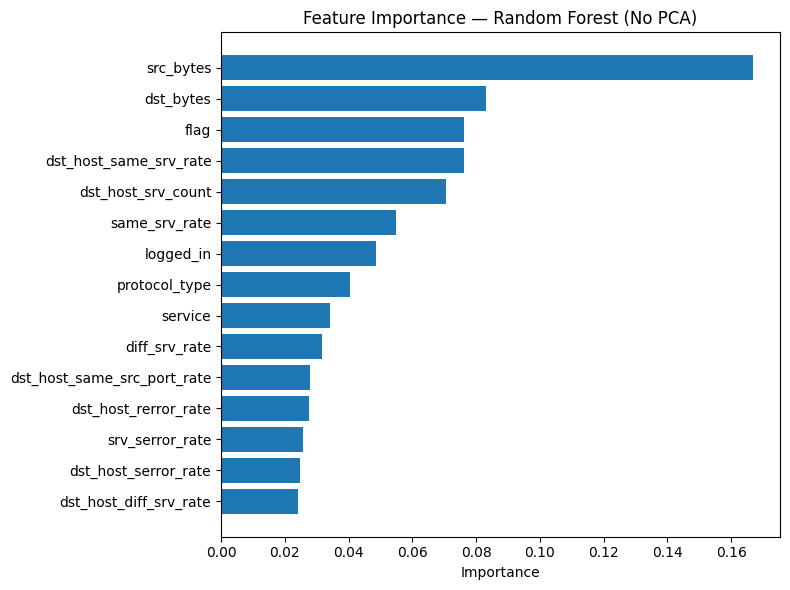

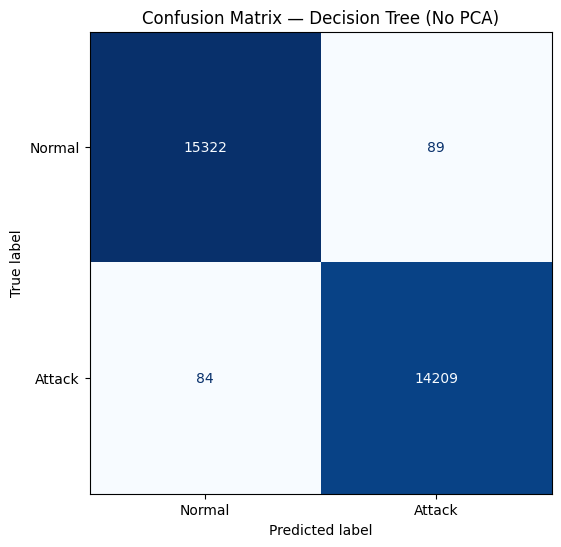

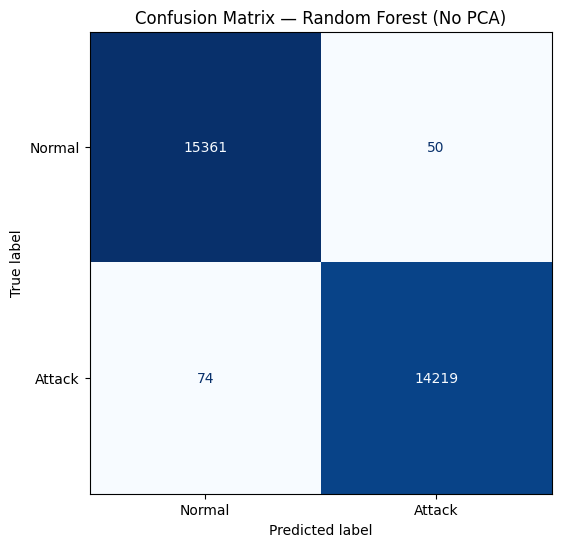

In [10]:
# ------------------------------------------------------------
# 8a. FINAL BINARY COMPARISON TABLE
# ------------------------------------------------------------
binary_df = pd.DataFrame(binary_results)
pivot = binary_df.pivot(index="Model", columns="Variant", values="Accuracy") * 100
pivot = pivot[["No PCA", "PCA (sklearn)", "PCA (from-scratch)"]].round(2)

print("\n" + "=" * 60 + "\nFINAL BINARY COMPARISON TABLE (Accuracy %)\n" + "=" * 60)
print(pivot.to_string())
print(f"\nsklearn PCA fit+transform time: {sklearn_time:.3f}s")
print(f"OptimizedPCA fit+transform time: {custom_time:.3f}s")
print("\nNOTE: 'PCA (sklearn)' and 'PCA (from-scratch)' should be nearly identical")
print("(within floating-point precision), confirming the from-scratch version is")
print("mathematically correct and production-equivalent to the library version.")

# ------------------------------------------------------------
# 8b. Feature Importance — Decision Tree & Random Forest
#     (No-PCA variant only: PCA components aren't directly
#     interpretable as original features, so importance plots
#     are shown for the raw-feature models)
# ------------------------------------------------------------
feature_names = x_all.columns.tolist()

no_pca_results = [r for r in binary_results if r["Variant"] == "No PCA"]
dt_no_pca_model = next(
    r["_fitted_model"] for r in no_pca_results if r["Model"] == "Decision Tree"
)
rf_no_pca_model = next(
    r["_fitted_model"] for r in no_pca_results if r["Model"] == "Random Forest"
)

plot_feature_importance(
    dt_no_pca_model, feature_names, "Feature Importance — Decision Tree (No PCA)"
)
plot_feature_importance(
    rf_no_pca_model, feature_names, "Feature Importance — Random Forest (No PCA)"
)

# ------------------------------------------------------------
# 8c. Confusion Matrix Visualization — No PCA variant
# ------------------------------------------------------------
dt_no_pca_cm = next(
    r["_confusion_matrix"] for r in no_pca_results if r["Model"] == "Decision Tree"
)
rf_no_pca_cm = next(
    r["_confusion_matrix"] for r in no_pca_results if r["Model"] == "Random Forest"
)

plot_confusion_matrix_display(
    dt_no_pca_cm, ["Normal", "Attack"], "Confusion Matrix — Decision Tree (No PCA)"
)
plot_confusion_matrix_display(
    rf_no_pca_cm, ["Normal", "Attack"], "Confusion Matrix — Random Forest (No PCA)"
)

In [11]:
# ------------------------------------------------------------
# 9. MULTICLASS EXTENSION — same 60/20/20 split logic, 5-category target
#    Note: reuses the DT/RF hyperparameters tuned on the BINARY task
#    above (search cost is not repeated); stated explicitly here rather
#    than silently assumed.
# ------------------------------------------------------------
x_train_full_mc, x_test_mc, y_train_full_mc, y_test_mc = train_test_split(
    x_all,
    y_all_multiclass,
    test_size=0.2,
    stratify=y_all_multiclass,
    random_state=RANDOM_SEED,
)
x_tr_mc, x_val_mc, y_tr_mc, y_val_mc = train_test_split(
    x_train_full_mc,
    y_train_full_mc,
    test_size=0.25,
    stratify=y_train_full_mc,
    random_state=RANDOM_SEED,
)

# Separate scaler instance — avoids silently overwriting the binary
# task's already-fitted `scaler` object
scaler_mc = RobustScaler()
x_tr_mc_scaled = scaler_mc.fit_transform(x_tr_mc)
x_test_mc_scaled = scaler_mc.transform(x_test_mc)

# PCA fit ONLY on multiclass train split (same no-leakage discipline
# as the binary task — PCA never sees validation or test rows during fit)
pca_mc = SklearnPCA(n_components="mle", svd_solver="full", random_state=RANDOM_SEED)
x_tr_mc_pca = pca_mc.fit_transform(x_tr_mc_scaled)
x_test_mc_pca = pca_mc.transform(x_test_mc_scaled)

print(f"Multiclass — Train: {len(x_tr_mc)} | Test: {len(x_test_mc)}")
print(
    f"Multiclass PCA components: {x_tr_mc_pca.shape[1]} | "
    f"Variance retained: {pca_mc.explained_variance_ratio_.sum():.4f}"
)

Multiclass — Train: 89109 | Test: 29704
Multiclass PCA components: 40 | Variance retained: 1.0000


In [12]:
# %%
# ------------------------------------------------------------
# 10. MULTICLASS — run across both feature-space variants
# ------------------------------------------------------------
multiclass_variants = {
    "No PCA": (x_tr_mc_scaled, x_test_mc_scaled),
    "PCA": (x_tr_mc_pca, x_test_mc_pca),
}

multiclass_results = []
for variant_label, (x_tr_v, x_test_v) in multiclass_variants.items():
    models = build_models(dt_params, rf_params)
    multiclass_results.extend(
        run_multiclass_experiment(
            models, x_tr_v, y_tr_mc, x_test_v, y_test_mc, variant_label
        )
    )


MULTICLASS — No PCA

Decision Tree: Accuracy=0.9943 (99.43%)
  Macro:    Precision=0.9433 Recall=0.9528 F1=0.9480
  Weighted: Precision=0.9944 Recall=0.9943 F1=0.9943
    DoS: Precision=0.998 Recall=0.999 F1=0.999 Support=10678
    Normal: Precision=0.996 Recall=0.995 F1=0.995 Support=15411
    Probe: Precision=0.994 Recall=0.988 F1=0.991 Support=2815
    R2L: Precision=0.929 Recall=0.948 F1=0.939 Support=776
    U2R: Precision=0.800 Recall=0.833 F1=0.816 Support=24

Ensemble (DT+RF): Accuracy=0.9944 (99.44%)
  Macro:    Precision=0.9352 Recall=0.9450 F1=0.9400
  Weighted: Precision=0.9945 Recall=0.9944 F1=0.9944
    DoS: Precision=0.998 Recall=0.999 F1=0.999 Support=10678
    Normal: Precision=0.996 Recall=0.994 F1=0.995 Support=15411
    Probe: Precision=0.994 Recall=0.990 F1=0.992 Support=2815
    R2L: Precision=0.928 Recall=0.950 F1=0.939 Support=776
    U2R: Precision=0.760 Recall=0.792 F1=0.776 Support=24

Random Forest: Accuracy=0.9950 (99.50%)
  Macro:    Precision=0.9593 Reca

In [13]:
# ------------------------------------------------------------
# 10. MULTICLASS — run across both feature-space variants
# ------------------------------------------------------------
multiclass_variants = {
    "No PCA": (x_tr_mc_scaled, x_test_mc_scaled),
    "PCA": (x_tr_mc_pca, x_test_mc_pca),
}

multiclass_results = []
for variant_label, (x_tr_v, x_test_v) in multiclass_variants.items():
    models = build_models(dt_params, rf_params)
    multiclass_results.extend(
        run_multiclass_experiment(
            models, x_tr_v, y_tr_mc, x_test_v, y_test_mc, variant_label
        )
    )


MULTICLASS — No PCA

Decision Tree: Accuracy=0.9943 (99.43%)
  Macro:    Precision=0.9433 Recall=0.9528 F1=0.9480
  Weighted: Precision=0.9944 Recall=0.9943 F1=0.9943
    DoS: Precision=0.998 Recall=0.999 F1=0.999 Support=10678
    Normal: Precision=0.996 Recall=0.995 F1=0.995 Support=15411
    Probe: Precision=0.994 Recall=0.988 F1=0.991 Support=2815
    R2L: Precision=0.929 Recall=0.948 F1=0.939 Support=776
    U2R: Precision=0.800 Recall=0.833 F1=0.816 Support=24

Ensemble (DT+RF): Accuracy=0.9944 (99.44%)
  Macro:    Precision=0.9352 Recall=0.9450 F1=0.9400
  Weighted: Precision=0.9945 Recall=0.9944 F1=0.9944
    DoS: Precision=0.998 Recall=0.999 F1=0.999 Support=10678
    Normal: Precision=0.996 Recall=0.994 F1=0.995 Support=15411
    Probe: Precision=0.994 Recall=0.990 F1=0.992 Support=2815
    R2L: Precision=0.928 Recall=0.950 F1=0.939 Support=776
    U2R: Precision=0.760 Recall=0.792 F1=0.776 Support=24

Random Forest: Accuracy=0.9950 (99.50%)
  Macro:    Precision=0.9593 Reca